## Centralidad

$C_D(v) = \frac{deg(v)}{n-1}$
donde $deg(v)$ es el grado del vertice v y n = |V|

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

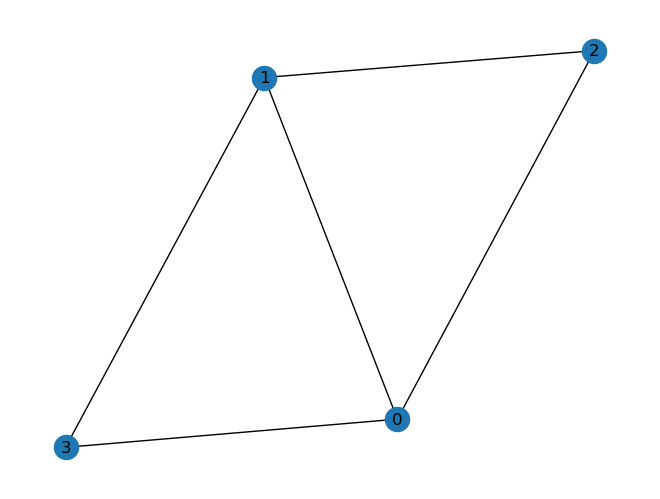

In [2]:
G1= nx.Graph([(0,1),(0,2),(0,3),(1,2),(1,3)])
nx.draw(G1, with_labels = True)

In [3]:
nx.degree_centrality(G1)

{0: 1.0, 1: 1.0, 2: 0.6666666666666666, 3: 0.6666666666666666}

In [4]:
K= nx.karate_club_graph()
print('#Nodos=', K.number_of_nodes())
print('Aristas=', K.number_of_edges())

#Nodos= 34
Aristas= 78


In [5]:
c_k = nx.degree_centrality(K)
sorted(list(c_k.values()))
max(c_k, key= c_k.get)

33

## Centralidad del eigenvector

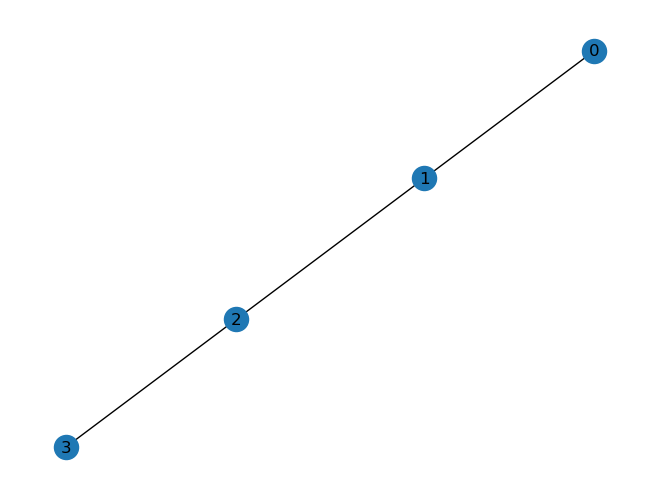

In [6]:
G = nx.path_graph(4)
nx.draw(G, with_labels = True)

In [7]:
ec = nx.eigenvector_centrality(K)
max(ec,key =ec.get)

33

In [8]:
import numpy as np
n = nx.to_numpy_array(G)
print(n)
eig , vec = np.linalg.eig(n)

[[0. 1. 0. 0.]
 [1. 0. 1. 0.]
 [0. 1. 0. 1.]
 [0. 0. 1. 0.]]


In [9]:
## Centralidad de Katz

In [10]:
import math
G = nx.path_graph(4)
phi = (1 + math.sqrt(5))/2.0
centrality = nx.katz_centrality(G,1/phi-0.01)
centrality

{0: 0.37341657312647464,
 1: 0.6004665377142012,
 2: 0.6004665377142012,
 3: 0.37341657312647464}

## Page Rank

In [11]:
nx.pagerank(G, alpha = 0.9)

{0: 0.1724140124772394,
 1: 0.3275859875227606,
 2: 0.3275859875227606,
 3: 0.1724140124772394}

## Centralidad de Cercanían
$C(v) = \frac{n-1}{\sum_{v=1}^{n-1}{d(u,v)}}$

In [12]:
nx.closeness_centrality(K)

{0: 0.5689655172413793,
 1: 0.4852941176470588,
 2: 0.559322033898305,
 3: 0.4647887323943662,
 4: 0.3793103448275862,
 5: 0.38372093023255816,
 6: 0.38372093023255816,
 7: 0.44,
 8: 0.515625,
 9: 0.4342105263157895,
 10: 0.3793103448275862,
 11: 0.36666666666666664,
 12: 0.3707865168539326,
 13: 0.515625,
 14: 0.3707865168539326,
 15: 0.3707865168539326,
 16: 0.28448275862068967,
 17: 0.375,
 18: 0.3707865168539326,
 19: 0.5,
 20: 0.3707865168539326,
 21: 0.375,
 22: 0.3707865168539326,
 23: 0.39285714285714285,
 24: 0.375,
 25: 0.375,
 26: 0.3626373626373626,
 27: 0.4583333333333333,
 28: 0.4520547945205479,
 29: 0.38372093023255816,
 30: 0.4583333333333333,
 31: 0.5409836065573771,
 32: 0.515625,
 33: 0.55}

## Betweenness Centrality

In [13]:
G = nx.path_graph(3)
nx.betweenness_centrality(G, normalized = False, endpoints = False)

{0: 0.0, 1: 1.0, 2: 0.0}

In [14]:
nx.betweenness_centrality(G, normalized = False, endpoints = True)

{0: 2.0, 1: 3.0, 2: 2.0}

# Cliques

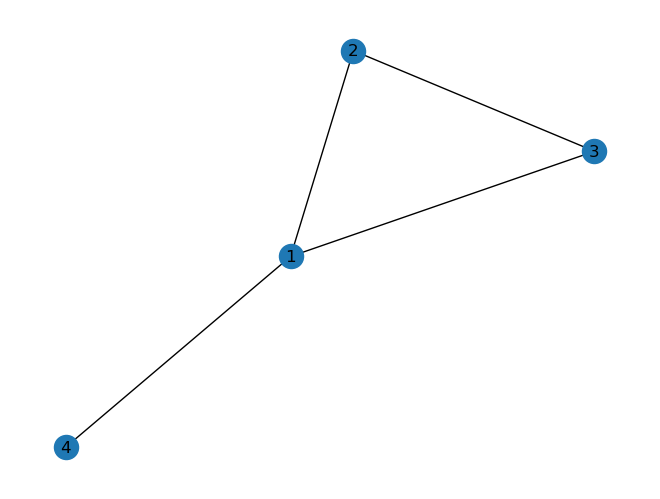

In [15]:
G = nx.Graph()
G.add_edges_from([(1,2),(1,3),(2,3),(1,4)])
pos = nx.spring_layout(G, seed = 7)
nx.draw(G, pos , with_labels= True)

In [16]:
maximal_cliques = list(nx.find_cliques(G))
maximal_cliques

[[1, 2, 3], [1, 4]]

In [17]:
clique_maxima = max(nx.find_cliques(G), key = len)
len(clique_maxima), clique_maxima

(3, [1, 2, 3])

In [18]:
nx.number_of_cliques(G)

{1: 2, 2: 1, 3: 1, 4: 1}

In [19]:
nx.node_clique_number(G) #Tamaño de la clica maxima en la que esta

defaultdict(int, {1: 3, 2: 3, 3: 3, 4: 2})

In [20]:
all_cliques = list(nx.enumerate_all_cliques(G))
all_cliques

[[1], [2], [3], [4], [1, 2], [1, 3], [1, 4], [2, 3], [1, 2, 3]]

In [21]:
C4 = nx.cycle_graph(4)
clique_maxima = max(nx.find_cliques(C4), key = len)
len(clique_maxima), clique_maxima

(2, [0, 1])

In [22]:
largest = max(nx.find_cliques(K), key = len)
len(largest), largest

(5, [0, 1, 2, 3, 13])

In [23]:
len(list(nx.find_cliques(K)))

36

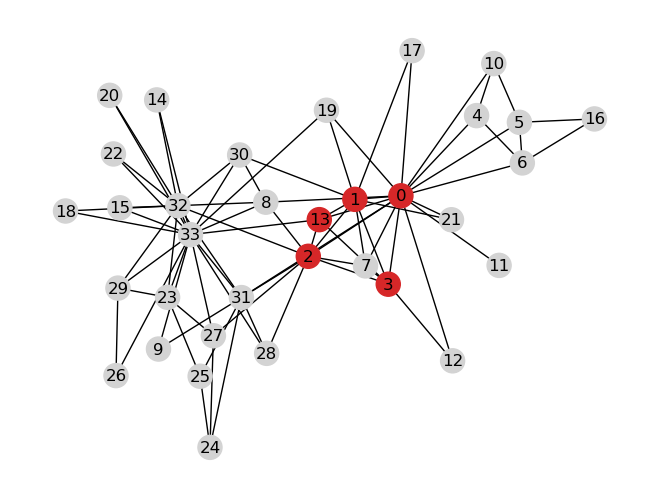

In [24]:
pos = nx.spring_layout(K, seed = 4)
largest_set = set(largest)
node_colors = ['tab:red' if n in largest_set else 'lightgray'for n in K.nodes()]
nx.draw(K, pos, with_labels= True, node_color = node_colors)

In [25]:
H = nx.Graph()
H.add_edges_from([('A','B'),('A','C'),('B','C'),('C','D'),('C','E'),('D','E')])
pesos = {'A': 2, 'B': 3, 'C':  5, 'D': 4,'E': 1 }
nx.set_node_attributes(H,pesos,'peso')

In [26]:
clique_pesada, peso_total = nx.max_weight_clique(H, weight= 'peso')
clique_pesada,peso_total

(['E', 'D', 'C'], 10)

# Comunidades con K cliques

In [27]:
from networkx.algorithms.community import k_clique_communities

In [28]:
K = nx.karate_club_graph()

In [29]:
 cliques_k= list(k_clique_communities(K, k=3))
community =list(cliques_k[0])

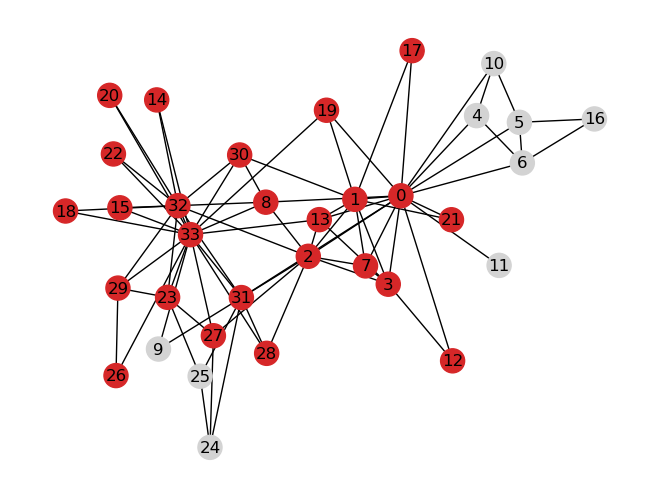

In [30]:
pos = nx.spring_layout(K, seed = 4)
largest_set = set(community)
node_colors = ['tab:red' if n in largest_set else 'lightgray'for n in K.nodes()]
nx.draw(K, pos, with_labels= True, node_color = node_colors)

In [31]:
G = nx.complete_graph(5)
K5 = nx.convert_node_labels_to_integers(G, first_label= 2)
G.add_edges_from(K5.edges())
c = list(k_clique_communities(G,4))
c

[frozenset({0, 1, 2, 3, 4, 5, 6})]

In [32]:
# Ejercicio 1
G = nx.path_graph(5)
maximal_cliques = list(nx.find_cliques(G))
maximal_cliques

[[1, 0], [1, 2], [3, 2], [3, 4]]

In [33]:
clique_maxima = max(nx.find_cliques(G), key = len)
len(clique_maxima), clique_maxima

(2, [1, 0])

Ejercicio 4: Usa nx.karate_club_graph():

Encuentra una clique máxima.
Calcula cuántas cliques maximales hay.
Identifica los nodos con mayor number_of_cliques.

In [34]:
K = nx.karate_club_graph()
clique_maxima = max(nx.find_cliques(K), key = len)
len(clique_maxima), clique_maxima

(5, [0, 1, 2, 3, 13])

In [35]:
k_list = list(nx.find_cliques(K))
k2 = []
for k in k_list:
    if len(k)==len(clique_maxima):
        k2.append(k)

len(k2)

2

In [36]:
c = dict(nx.number_of_cliques(K))
max(c,key = c.get)

33

# K-componentes

In [37]:
plt.rcParams["figure.figsize"] = (6, 4)

def dibuja(G, pos=None, title=None):
    if pos is None:
        pos = nx.spring_layout(G, seed=7)
    nx.draw(G, pos, with_labels=True, node_size=900, font_size=11)
    if title:
        plt.title(title)
    plt.show()
    return pos

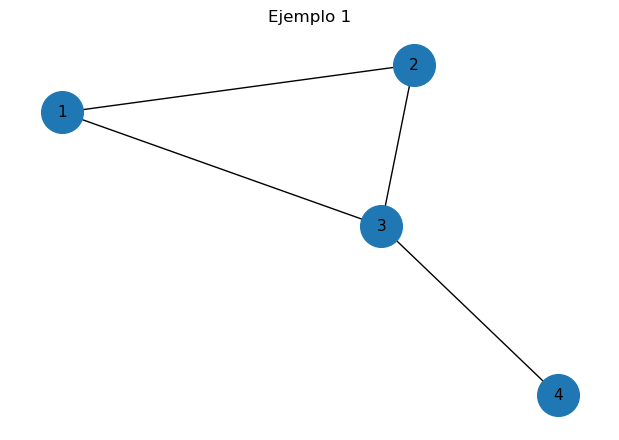

{1: array([-0.53766824,  0.44547381]),
 2: array([0.11044447, 0.68944626]),
 3: array([ 0.05078868, -0.13492008]),
 4: array([ 0.3764351, -1.       ])}

In [38]:
G = nx.Graph()
G.add_edges_from([(1,2),(2,3),(1,3),(3,4)])
dibuja(G,pos = None,title ='Ejemplo 1')

In [39]:
print('k-edge-componentes con k=2')
print(list(nx.k_edge_components(G,k=2)))

k-edge-componentes con k=2
[{1, 2, 3}, {4}]


In [40]:
print('Edge conectivity global', nx.edge_connectivity(G))


Edge conectivity global 1


In [41]:
print('node conectivity global', nx.node_connectivity(G))

node conectivity global 1


In [42]:
print('k-components', nx.k_components(G))

k-components {2: [{1, 2, 3}], 1: [{1, 2, 3, 4}]}


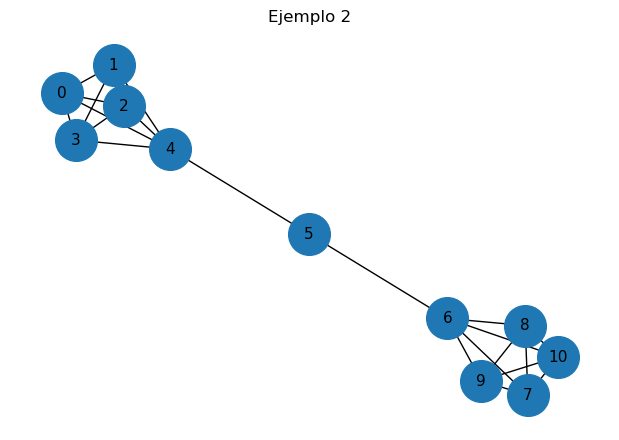

{0: array([-0.98826821,  0.64528116]),
 1: array([-0.78142349,  0.77751078]),
 2: array([-0.73910013,  0.5879014 ]),
 3: array([-0.93393892,  0.42947798]),
 4: array([-0.55532554,  0.38802534]),
 6: array([ 0.55672401, -0.39458568]),
 7: array([ 0.87950071, -0.74942003]),
 8: array([ 0.86874596, -0.42736947]),
 9: array([ 0.6928635, -0.6825695]),
 10: array([ 1.        , -0.57132759]),
 5: array([ 0.00022211, -0.0029244 ])}

In [43]:
B = nx.barbell_graph(5,1)
dibuja(B, None, "Ejemplo 2")

In [44]:
print('k-components',list( nx.k_edge_components(B,k=2)))
print('k-components',nx.k_components(B))

k-components [{0, 1, 2, 3, 4}, {6, 7, 8, 9, 10}, {5}]
k-components {4: [{6, 7, 8, 9, 10}, {0, 1, 2, 3, 4}], 3: [{6, 7, 8, 9, 10}, {0, 1, 2, 3, 4}], 2: [{6, 7, 8, 9, 10}, {0, 1, 2, 3, 4}], 1: [{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10}]}


In [45]:
print('Puentes', list(nx.bridges(G)))

Puentes [(3, 4)]


In [46]:
print('Puntos de articulacion:', list(nx.articulation_points(B)))

Puntos de articulacion: [6, 5, 4]


In [47]:
print(nx.edge_connectivity(K))
print(nx.node_connectivity(K))

1
1


In [48]:
print('k-components',list( nx.k_edge_components(B,k=2)))
print('k-components',nx.k_components(K))


k-components [{0, 1, 2, 3, 4}, {6, 7, 8, 9, 10}, {5}]
k-components {4: [{0, 33, 2, 3, 1, 32, 7, 8, 13, 30}], 3: [{0, 1, 2, 3, 7, 8, 13, 19, 23, 24, 25, 27, 28, 29, 30, 31, 32, 33}, {0, 4, 5, 6, 10}], 2: [{0, 1, 2, 3, 7, 8, 9, 12, 13, 14, 15, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33}, {0, 16, 4, 5, 6, 10}], 1: [{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33}]}


Ejercicio 1

In [49]:
G = nx.path_graph(6)
#Calculo la conectividad por nodos y por aritsa
print(nx.node_connectivity(G))
print(nx.edge_connectivity(G))
#Calculo los k componentes por arista
print(list(nx.k_edge_components(G, k=1)))

print(list(nx.k_edge_components(G, k=2)))

1
1
[{0, 1, 2, 3, 4, 5}]
[{0}, {1}, {2}, {3}, {4}, {5}]


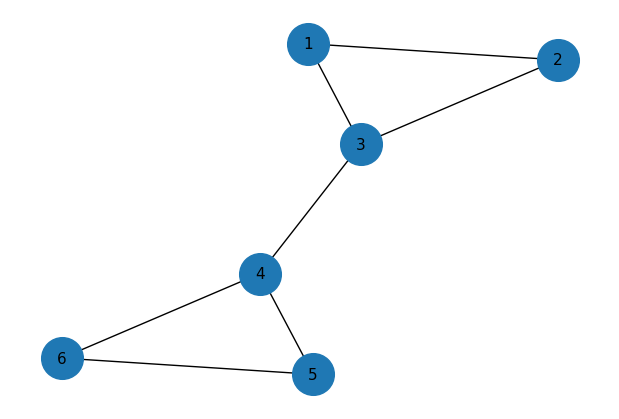

[{1, 2, 3}, {4, 5, 6}]
{2: [{4, 5, 6}, {1, 2, 3}], 1: [{1, 2, 3, 4, 5, 6}]}


In [50]:
G = nx.Graph([(1,2),(2,3),(3,1),(3,4),(4,5),(5,6),(6,4)])
dibuja(G)
print(list(nx.k_edge_components(G, k=2)))
print(dict(nx.k_components(G)))

# Transitividad y coeficiente de clustering

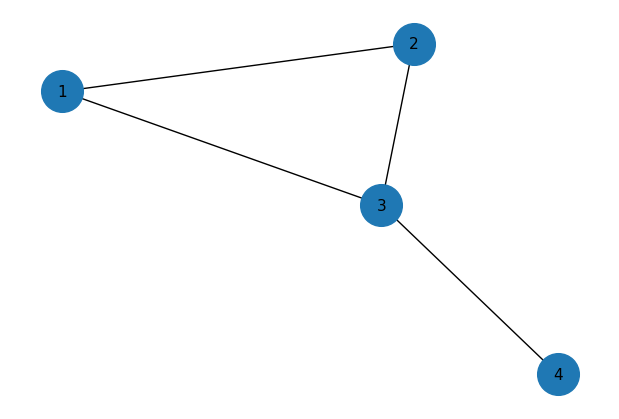

{1: array([-0.53766824,  0.44547381]),
 2: array([0.11044447, 0.68944626]),
 3: array([ 0.05078868, -0.13492008]),
 4: array([ 0.3764351, -1.       ])}

In [51]:
G = nx.Graph()
G.add_edges_from([(1,2),(2,3),(1,3),(3,4)])
dibuja(G)

In [52]:
print(nx.triangles(G))

{1: 1, 2: 1, 3: 1, 4: 0}


In [53]:
print(nx.triangles(G,3))

1


In [54]:
list(nx.all_triangles(G))

[(1, 2, 3)]

In [55]:
nx.clustering(G)

{1: 1.0, 2: 1.0, 3: 0.3333333333333333, 4: 0}

In [56]:
nx.average_clustering(G)

0.5833333333333334

In [57]:
nx.average_clustering(G, count_zeros=False)

0.7777777777777778

In [58]:
nx.transitivity(G)

0.6

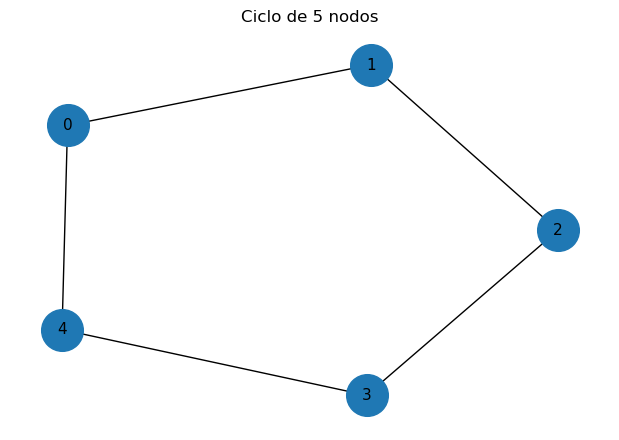

{0: array([-0.79713842,  0.5943602 ]),
 1: array([0.31575201, 0.94288975]),
 2: array([ 1.        , -0.00743443]),
 3: array([ 0.29853248, -0.95335166]),
 4: array([-0.81714608, -0.57646386])}

In [59]:
C = nx.cycle_graph(5)
dibuja(C,None, title = 'Ciclo de 5 nodos')

In [60]:
nx.clustering(C)

{0: 0, 1: 0, 2: 0, 3: 0, 4: 0}

In [61]:
nx.transitivity(C)

0

In [62]:
G =nx.complete_graph(4)
print(nx.average_clustering(G))
print(nx.clustering(G))
print(nx.transitivity(G))

1.0
{0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0}
1.0


In [63]:
print(nx.square_clustering(G))

{0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0}


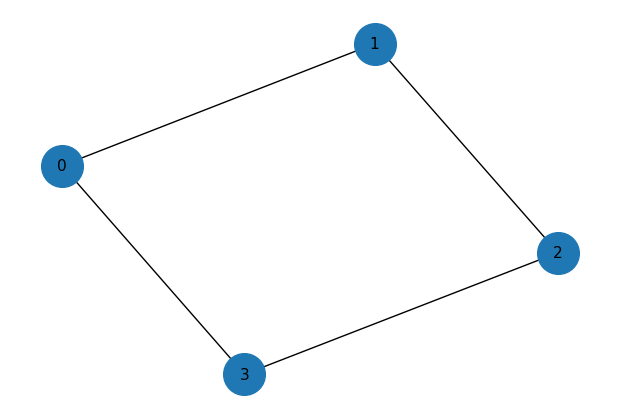

{0: array([-0.99831125,  0.26183894]),
 1: array([0.26152246, 0.99685993]),
 2: array([ 1.        , -0.26271647]),
 3: array([-0.26321121, -0.99598239])}

In [64]:
B= nx.cycle_graph(4)
dibuja(B)

In [65]:
nx.square_clustering(B)


{0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0}

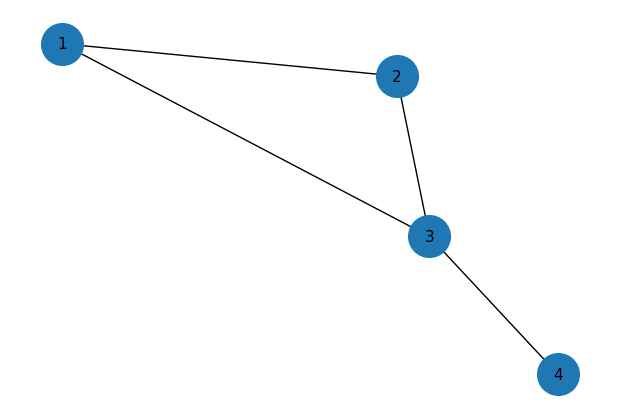

{1: array([-0.6251008 ,  0.72484159]),
 2: array([0.07340156, 0.55611909]),
 3: array([ 0.14179106, -0.28096068]),
 4: array([ 0.40990818, -1.        ])}

In [66]:
W = nx.Graph()
W.add_weighted_edges_from([(1,2,3.0),(2,3,3.0),(1,3,1.0),(3,4,5.0)])
dibuja(W)

In [67]:
nx.clustering(W)


{1: 1.0, 2: 1.0, 3: 0.3333333333333333, 4: 0}

In [68]:
nx.clustering(W,weight = 'weight')


{1: 0.41601676461038084, 2: 0.41601676461038084, 3: 0.13867225487012694, 4: 0}

In [69]:
nx.average_clustering(W, weight = 'weight')

0.24267644602272215

In [70]:
K = nx.karate_club_graph()
print(nx.transitivity(K))
clus = nx.clustering(K)
print(max(clus,key =clus.get ))
print(nx.average_clustering(K))
triangles = nx.all_triangles(K)
print(len(list(triangles)))

0.2556818181818182
7
0.5706384782076823
45


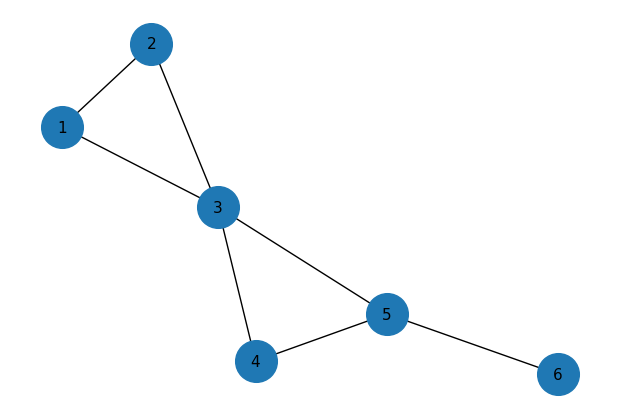

{1: 1.0, 2: 1.0, 3: 0.3333333333333333, 4: 1.0, 5: 0.3333333333333333, 6: 0}
[(1, 2, 3), (3, 4, 5)]


In [71]:
G = nx.Graph([(1,2),(2,3),(3,1),(3,4),(4,5),(5,3),(5,6)])
dibuja(G)
triangles = nx.all_triangles(G)
print(nx.clustering(G))
print(list(triangles))
clus = nx.clustering(G)
#El 3 es el que participa en mas triangulos

In [72]:
G = nx.complete_graph(5)
print(nx.triangles(G))
print(nx.average_clustering(G))
print(nx.transitivity(G))

{0: 6, 1: 6, 2: 6, 3: 6, 4: 6}
1.0
1.0


In [73]:
plt.rcParams["figure.figsize"] = (6, 4)

def dibuja_colors(G, pos=None, title=None, node_color = 'lightblue'):
    if pos is None:
        pos = nx.spring_layout(G, seed=7)
    nx.draw(G, pos, with_labels=True, node_size=900, font_size=11,node_color = node_color)
    if title:
        plt.title(title)
    plt.show()
    return pos

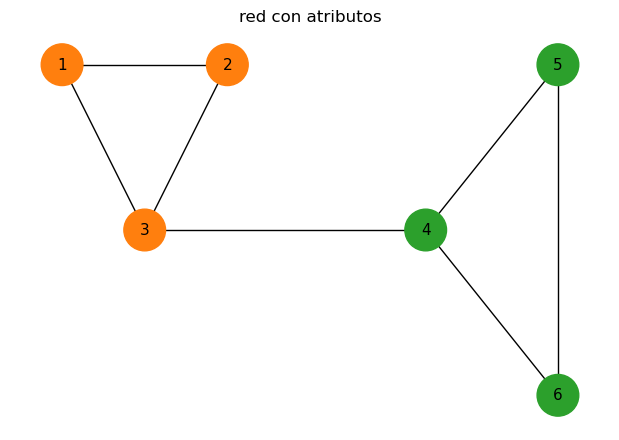

{1: (0, 1), 2: (1, 1), 3: (0.5, 0), 4: (2.2, 0), 5: (3.0, 1), 6: (3.0, -1)}

In [74]:
G = nx.Graph()
G.add_edges_from([(1,2),(1,3),(2,3),(3,4),(4,5),(5,6),(4,6)])

attrs = {
 1: {'group': 'A', 'score':10},
2: {'group': 'A', 'score':12},
    3: {'group': 'A', 'score':11},
    4: {'group': 'B', 'score':30},
    5: {'group': 'B', 'score':28},
    6:{'group': 'B', 'score':32}

}

nx.set_node_attributes(G,attrs)

pos = {
    1: (0,1), 2: (1,1),3: (0.5,0), 4: (2.2,0), 5: (3.0,1), 6: (3.0,-1)
}

colors = ['tab:orange' if G.nodes[n]['group']=='A' else 'tab:green' for n in G.nodes()]
dibuja_colors(G,pos,'red con atributos', node_color = colors)

In [75]:
nx.degree_assortativity_coefficient(G)

-0.16666666666666508

In [76]:
nx.degree_pearson_correlation_coefficient(G)

-0.16666666666666652

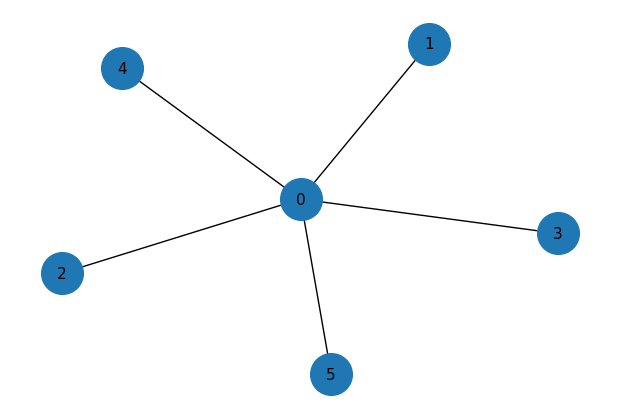

{0: array([ 0.00044569, -0.00253284]),
 1: array([0.49392508, 0.88222637]),
 2: array([-0.91602171, -0.42407905]),
 3: array([ 0.98968221, -0.19825987]),
 4: array([-0.68645929,  0.74264539]),
 5: array([ 0.11842802, -1.        ])}

In [77]:
S = nx.star_graph(5)
posS = nx.spring_layout(S, seed=4)
dibuja(S, posS)

In [78]:
nx.degree_assortativity_coefficient(S)

-1.0

In [79]:
nx.degree_pearson_correlation_coefficient(S)

-0.9999999999999999

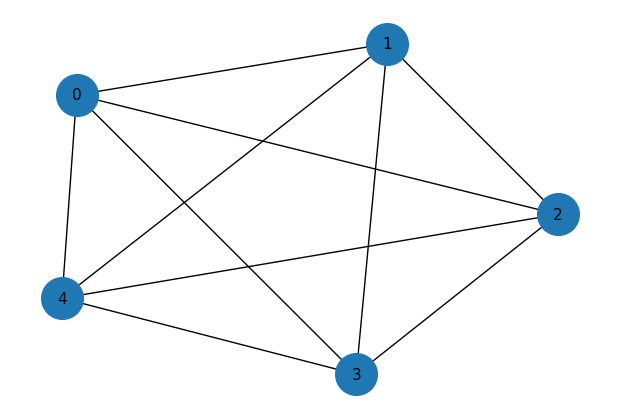

{0: array([-0.78347096,  0.63644238]),
 1: array([0.3678388 , 0.93189418]),
 2: array([ 1.        , -0.05347412]),
 3: array([ 0.25279808, -0.97719739]),
 4: array([-0.83716592, -0.53766505])}

In [80]:
compl = nx.complete_graph(5)
dibuja(compl)

In [81]:
nx.degree_assortativity_coefficient(compl)

/home/gdiek/anaconda3/lib/python3.13/site-packages/networkx/algorithms/assortativity/correlation.py:302: RuntimeWarning: invalid value encountered in scalar divide
  return float((xy * (M - ab)).sum() / np.sqrt(vara * varb))


nan

In [82]:
nx.degree_pearson_correlation_coefficient(compl)

/home/gdiek/anaconda3/lib/python3.13/site-packages/networkx/algorithms/assortativity/correlation.py:159: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return float(sp.stats.pearsonr(x, y)[0])


nan

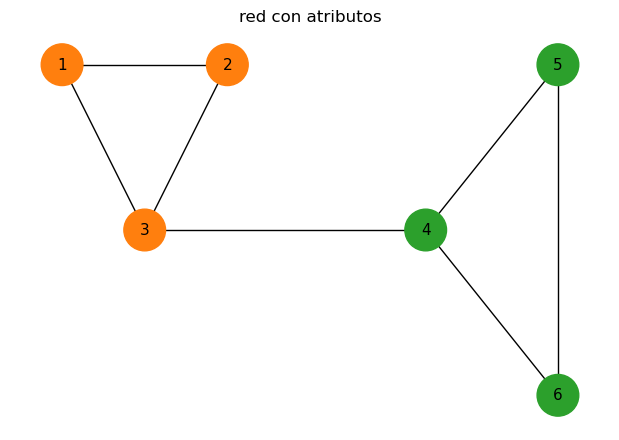

{1: (0, 1), 2: (1, 1), 3: (0.5, 0), 4: (2.2, 0), 5: (3.0, 1), 6: (3.0, -1)}

In [83]:
G = nx.Graph()
G.add_edges_from([(1,2),(1,3),(2,3),(3,4),(4,5),(5,6),(4,6)])

attrs = {
 1: {'group': 'A', 'score':10},
2: {'group': 'A', 'score':12},
    3: {'group': 'A', 'score':11},
    4: {'group': 'B', 'score':30},
    5: {'group': 'B', 'score':28},
    6:{'group': 'B', 'score':32}

}

nx.set_node_attributes(G,attrs)

pos = {
    1: (0,1), 2: (1,1),3: (0.5,0), 4: (2.2,0), 5: (3.0,1), 6: (3.0,-1)
}

colors = ['tab:orange' if G.nodes[n]['group']=='A' else 'tab:green' for n in G.nodes()]
dibuja_colors(G,pos,'red con atributos', node_color = colors)

In [84]:
nx.attribute_assortativity_coefficient(G,'group')

0.7142857142857143

In [85]:
nx.numeric_assortativity_coefficient(G, 'score')

0.6953642384105958

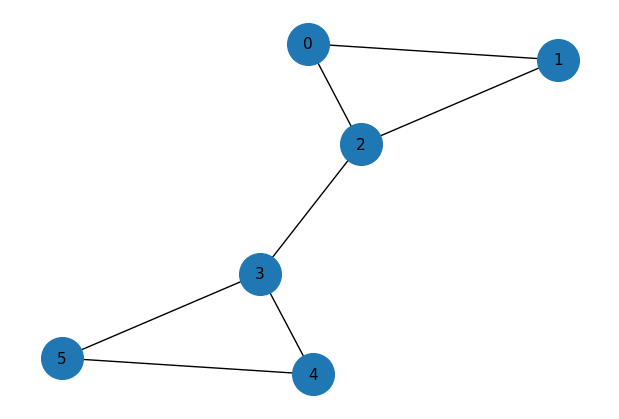

{0: array([-0.00412317,  0.99960753]),
 1: array([0.43111913, 0.90189227]),
 2: array([0.08779881, 0.39110087]),
 3: array([-0.08774124, -0.39062571]),
 4: array([ 0.00489938, -1.        ]),
 5: array([-0.43195291, -0.90197495])}

In [86]:
B = nx.barbell_graph(3,0)
dibuja(B)


In [87]:
nx.community.modularity(G, [{1,2,3},{4,5,6}])

0.35714285714285715

156
1437


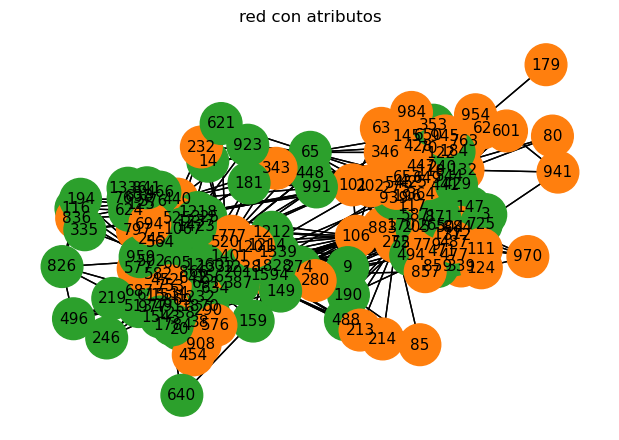

{1: array([0.50945366, 0.07460267]),
 883: array([0.32532572, 0.02096923]),
 132: array([0.63380212, 0.2931221 ]),
 339: array([ 0.6267666 , -0.15945822]),
 653: array([0.42155593, 0.26006735]),
 545: array([0.38970882, 0.23368199]),
 171: array([ 0.57296756, -0.00859111]),
 117: array([0.43859949, 0.12340646]),
 196: array([0.41758565, 0.17109081]),
 587: array([0.44988397, 0.08189931]),
 372: array([ 0.61390924, -0.01208873]),
 147: array([0.66090646, 0.11701426]),
 55: array([ 0.39694174, -0.05314884]),
 859: array([ 0.5352256, -0.1620161]),
 106: array([ 0.22276876, -0.01905353]),
 504: array([0.58571105, 0.02509464]),
 471: array([ 0.55229922, -0.09192921]),
 425: array([0.44148091, 0.23673713]),
 170: array([0.39589815, 0.03467787]),
 939: array([0.36727561, 0.16021924]),
 272: array([ 0.37552536, -0.04583785]),
 3: array([0.72162466, 0.08295487]),
 119: array([0.51143393, 0.28757423]),
 494: array([ 0.4321554 , -0.10826781]),
 205: array([0.45496982, 0.02320597]),
 265: array([0

In [88]:
import pandas as pd
schoolfriends_edgelist = pd.read_csv(
  "https://ona-book.org/data/schoolfriends_edgelist.csv"
)
schoolfriends_vertices = pd.read_csv(
  "https://ona-book.org/data/schoolfriends_vertices.csv"
)

# Creamos una gráfica no dirigida de Facebook
schoolfriends_fb = nx.from_pandas_edgelist(
  df = schoolfriends_edgelist[
    schoolfriends_edgelist.type == 'facebook'
  ],
  source = "from",
  target = "to"
)

# Creamos una gráfica dirigida de las amistades reportadas

schoolfriends_rp = nx.from_pandas_edgelist(
  df = schoolfriends_edgelist[
    schoolfriends_edgelist.type == 'reported'
  ],
  source = "from",
  target = "to",
  create_using=nx.DiGraph()
)

# Agregamos los atributos de las clases de vértices a ambas gráficas
class_attr = dict(zip(schoolfriends_vertices['id'], schoolfriends_vertices['class']))
class_attr2 = dict(zip(schoolfriends_vertices['id'], schoolfriends_vertices['gender']))



nx.set_node_attributes(schoolfriends_fb, name = "class", values = class_attr)
nx.set_node_attributes(schoolfriends_fb, name = "gender", values = class_attr2)


nx.set_node_attributes(schoolfriends_rp, name = "class", values = class_attr)
pos = nx.spring_layout(schoolfriends_fb)

nx.draw(schoolfriends_fb,pos = pos)
print(nx.number_of_nodes(schoolfriends_fb))
print(nx.number_of_edges(schoolfriends_fb))


colors = ['tab:orange' if schoolfriends_fb.nodes[n]['gender']=='F' else 'tab:green' for n in schoolfriends_fb.nodes()]
dibuja_colors(schoolfriends_fb,pos,'red con atributos', node_color = colors)

In [89]:
nx.attribute_assortativity_coefficient(schoolfriends_fb,'class')


0.3833666875368265

In [90]:
nx.attribute_assortativity_coefficient(schoolfriends_fb,'gender')

0.12830844580604214

In [91]:
nx.attribute_assortativity_coefficient(schoolfriends_rp,'class')

0.7188918572576617

In [92]:
import json
data1 = json.load(open('toy_story.json'))['network']

G1 = nx.Graph()
G1.add_edges_from([(e['source'], e['target'], {'weight': e['weight']}) for e in data1['edges']])



Parte 1. Exploración básica Indica:

número de nodos,

número de aristas,

si la red es conexa o no.

Si no es conexa, reporta:

cuántas componentes conexas tiene,

el tamaño de cada componente,

cuál es la componente gigante.



In [93]:
G1.number_of_nodes()

39

In [94]:
G1.number_of_edges()

204

In [95]:
nx.is_connected(G1)

True

Parte 2. Centralidad

Calcula las siguientes medidas de centralidad para todos los nodos:

centralidad de grado,

centralidad de cercanía,

centralidad de intermediación (betweenness),

centralidad de vector propio (eigenvector centrality), si es posible.

Después:

Reporta los 5 personajes más importantes según cada medida.

Compara los resultados:

¿coinciden los personajes más importantes en todas las medidas?

¿qué tipo de “importancia” parece capturar cada centralidad?

In [96]:
dg_centrality =nx.degree_centrality(G1)
c_centrality = nx.closeness_centrality(G1)
b_centrality = nx.betweenness_centrality(G1)
eig_centrality = nx.eigenvector_centrality(G1)


In [97]:
sorted_dg = dict(sorted(dg_centrality.items(), key=lambda item: item[1]))
sorted_dg

{'MOM': 0.02631578947368421,
 'ROBOT GUARDS': 0.02631578947368421,
 'WOUNDED SOLDIER': 0.02631578947368421,
 "SID'S MOM": 0.07894736842105263,
 'ALIEN': 0.10526315789473684,
 'ATTENDANT': 0.13157894736842105,
 'PIZZA DELIVERER': 0.13157894736842105,
 'HANNAH': 0.13157894736842105,
 'KID #2': 0.18421052631578946,
 'TV ANNOUNCER': 0.18421052631578946,
 'SPACE COMMANDER': 0.18421052631578946,
 'KID #1': 0.18421052631578946,
 'LOCAL ANNOUNCER': 0.18421052631578946,
 'TV BUZZ': 0.18421052631578946,
 'MALE CHORUS': 0.18421052631578946,
 'ALIEN #2': 0.18421052631578946,
 'ALIEN #1': 0.18421052631578946,
 'ALIEN #3': 0.18421052631578946,
 'ALIEN #4': 0.18421052631578946,
 'ALIENS': 0.18421052631578946,
 'MR SPELL': 0.23684210526315788,
 'MIKE': 0.23684210526315788,
 'ROBOT': 0.23684210526315788,
 'LENNY': 0.2631578947368421,
 'FRIEND #2': 0.2894736842105263,
 'FRIEND #1': 0.2894736842105263,
 'RC CAR': 0.2894736842105263,
 'TOYS': 0.3157894736842105,
 'MRS DAVIS': 0.39473684210526316,
 'SARGEN

In [98]:
max(c_centrality, key = c_centrality.get)
sorted_c = dict(sorted(c_centrality.items(), key=lambda item: item[1]))
sorted_c

{'MOM': 0.3486238532110092,
 'WOUNDED SOLDIER': 0.4,
 'ROBOT GUARDS': 0.4810126582278481,
 'MR SPELL': 0.5,
 'MIKE': 0.5,
 "SID'S MOM": 0.5066666666666667,
 'ATTENDANT': 0.5205479452054794,
 'PIZZA DELIVERER': 0.5205479452054794,
 'KID #2': 0.5205479452054794,
 'TV ANNOUNCER': 0.5205479452054794,
 'SPACE COMMANDER': 0.5205479452054794,
 'KID #1': 0.5205479452054794,
 'LOCAL ANNOUNCER': 0.5205479452054794,
 'TV BUZZ': 0.5205479452054794,
 'MALE CHORUS': 0.5205479452054794,
 'ALIEN': 0.5205479452054794,
 'HANNAH': 0.5277777777777778,
 'ALIEN #2': 0.5352112676056338,
 'ALIEN #1': 0.5352112676056338,
 'ALIEN #3': 0.5352112676056338,
 'ALIEN #4': 0.5352112676056338,
 'ALIENS': 0.5352112676056338,
 'ROBOT': 0.5588235294117647,
 'LENNY': 0.5671641791044776,
 'FRIEND #2': 0.5757575757575758,
 'FRIEND #1': 0.5757575757575758,
 'RC CAR': 0.5757575757575758,
 'TOYS': 0.5846153846153846,
 'MRS DAVIS': 0.6129032258064516,
 'SARGENT': 0.6129032258064516,
 'ANDY': 0.6333333333333333,
 'HAMM': 0.64406

In [99]:
max(b_centrality,key= b_centrality.get)
sorted_b = dict(sorted(b_centrality.items(), key=lambda item: item[1]))
sorted_b

{'ATTENDANT': 0.0,
 'PIZZA DELIVERER': 0.0,
 'MR SPELL': 0.0,
 'MIKE': 0.0,
 'KID #2': 0.0,
 'TV ANNOUNCER': 0.0,
 'SPACE COMMANDER': 0.0,
 'KID #1': 0.0,
 'LOCAL ANNOUNCER': 0.0,
 'TV BUZZ': 0.0,
 'MALE CHORUS': 0.0,
 'MOM': 0.0,
 "SID'S MOM": 0.0,
 'ROBOT': 0.0,
 'FRIEND #2': 0.0,
 'FRIEND #1': 0.0,
 'RC CAR': 0.0,
 'ALIEN #2': 0.0,
 'ALIEN #1': 0.0,
 'ALIEN #3': 0.0,
 'ALIEN #4': 0.0,
 'ALIENS': 0.0,
 'ALIEN': 0.0,
 'ROBOT GUARDS': 0.0,
 'WOUNDED SOLDIER': 0.0,
 'LENNY': 0.00035561877667140827,
 'TOYS': 0.0007112375533428165,
 'SARGENT': 0.005547652916073969,
 'MRS DAVIS': 0.008392603129445233,
 'HAMM': 0.01088193456614509,
 'MR POTATO HEAD': 0.01088193456614509,
 'REX': 0.01088193456614509,
 'BO PEEP': 0.01088193456614509,
 'ANDY': 0.016216216216216214,
 'SID': 0.045045045045045036,
 'HANNAH': 0.052631578947368425,
 'SLINKY': 0.06351351351351352,
 'WOODY': 0.15407776197249884,
 'BUZZ': 0.4705784732100522}

In [100]:
max(eig_centrality, key = eig_centrality.get)
sorted_eig = dict(sorted(eig_centrality.items(), key=lambda item: item[1]))
sorted_eig

{'MOM': 0.0037937991678123925,
 'WOUNDED SOLDIER': 0.017466316636672214,
 'ROBOT GUARDS': 0.020063698508789227,
 'KID #2': 0.033549978263395695,
 'TV ANNOUNCER': 0.033549978263395695,
 'SPACE COMMANDER': 0.033549978263395695,
 'KID #1': 0.033549978263395695,
 'LOCAL ANNOUNCER': 0.033549978263395695,
 'TV BUZZ': 0.033549978263395695,
 'MALE CHORUS': 0.033549978263395695,
 "SID'S MOM": 0.05259749476141606,
 'ALIEN': 0.056391293929228446,
 'HANNAH': 0.056629496967525915,
 'ALIEN #2': 0.07185199195626946,
 'ALIEN #1': 0.07185199195626946,
 'ALIEN #3': 0.07185199195626946,
 'ALIEN #4': 0.07185199195626946,
 'ALIENS': 0.07185199195626946,
 'ATTENDANT': 0.07603307778252415,
 'PIZZA DELIVERER': 0.07603307778252415,
 'MR SPELL': 0.14846908925970398,
 'MIKE': 0.14846908925970398,
 'ROBOT': 0.1505481534298795,
 'LENNY': 0.16289723525398572,
 'SID': 0.18350375995289558,
 'FRIEND #2': 0.18572165671396937,
 'FRIEND #1': 0.18572165671396937,
 'RC CAR': 0.1864560410662224,
 'TOYS': 0.1966837978786972,

¿coinciden los personajes más importantes en todas las medidas?
No, pero si en la mayorias

¿qué tipo de “importancia” parece capturar cada centralidad? que tan aliado esta con los demas personajes

Parte 3. Cliques y cohesión local

Encuentra:

el tamaño del clique máximo,

el tamaño de clique maximo es de 12

un ejemplo de clique máximo,

cuántos cliques maximales hay en total.
hay 2

Interpreta el resultado:

¿qué representa un clique en esta red?
representa que tantas compartes los personajes entre ellos


¿un clique grande sugiere una escena muy compartida entre personajes o una fuerte relación narrativa?
representa mas bien una fuerte asociacion narrativa mas que una escena grande, aunque tambien es posible que exista una escena en la que aparezcan una buena parte de los personajes

In [101]:
list_clique=list(nx.find_cliques(G1))
list_len_clique = [len(x) for x in list_clique ]
len_max =max(list_len_clique)
for x in list_clique:
    if len(x) == len_max:
        print(x)
                        

['BUZZ', 'WOODY', 'ANDY', 'MRS DAVIS', 'REX', 'SLINKY', 'HAMM', 'SARGENT', 'BO PEEP', 'MR POTATO HEAD', 'RC CAR', 'TOYS']
['BUZZ', 'WOODY', 'ANDY', 'MRS DAVIS', 'REX', 'SLINKY', 'HAMM', 'SARGENT', 'BO PEEP', 'MR POTATO HEAD', 'FRIEND #1', 'FRIEND #2']


Parte 4. Conectividad global

Calcula la conectividad por nodos de la red.

Calcula la conectividad por aristas.

Encuentra un ejemplo de:

un conjunto mínimo de nodos cuya eliminación desconecte la red,

un conjunto mínimo de aristas cuya eliminación desconecte la red.

Interpreta:

¿la red parece robusta o frágil?: La red parece fragil 

¿hay personajes “puente” cuya ausencia rompería la historia en comunidades separadas?: si como es el caso de Hannah qu si bien es un personaje no muy importante funciona como puente para otros personajes



In [105]:
nx.node_connectivity(G1)

1

In [106]:
nx.edge_connectivity(G1)

1

In [107]:
nx.minimum_node_cut(G1)

{'HANNAH'}

In [108]:
nx.minimum_edge_cut(G1)

{('BUZZ', 'ROBOT GUARDS')}

Parte 5. k-componentes

Calcula los k-componentes de la red.

Reporta:

qué valores de k aparecen: Aparecen 11 k-componentes

cuántos k-componentes hay para cada k: de 4 a 1

cuál es el valor máximo de k: 11

Explica:

¿qué significa que un subconjunto pertenezca a un k-componente?:

que hay un grupo de personajes relacionados directamente entre ellos

¿qué nos dice esto sobre la cohesión de ciertos grupos de personajes?:

que ese grupo esta altamente conectado entre ellos

In [138]:
k_comp=nx.k_components(G1)
k_comp[11]
#print(k_comp)

[{'ANDY',
  'BO PEEP',
  'BUZZ',
  'HAMM',
  'MR POTATO HEAD',
  'MRS DAVIS',
  'RC CAR',
  'REX',
  'SARGENT',
  'SLINKY',
  'TOYS',
  'WOODY'},
 {'ANDY',
  'BO PEEP',
  'BUZZ',
  'FRIEND #1',
  'FRIEND #2',
  'HAMM',
  'MR POTATO HEAD',
  'MRS DAVIS',
  'REX',
  'SARGENT',
  'SLINKY',
  'WOODY'}]

In [136]:
value_list = list(k_comp.values())
key_list = list(k_comp.keys())
len_list = [len(i) for i in value_list]
print(key_list,len_list)


[11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1] [2, 1, 3, 1, 3, 3, 4, 4, 2, 2, 1]


Calcula la transitividad global de la red.

Calcula el coeficiente de clustering promedio.

Calcula el coeficiente de clustering local de cada nodo y reporta los 5 más altos.

Discute:

¿la red favorece triángulos? si parece que favorece triangulos la red debido a que tanto la transitividad como el average clustering son altos

¿los amigos de un personaje tienden también a relacionarse entre sí? Si los amigos de un personaje tambien son amigos entre elloos

In [129]:
nx.transitivity(G1)

0.6408475164987844

In [130]:
nx.average_clustering(G1)

0.8073579088800967

In [131]:
nx.clustering(G1)

{'ATTENDANT': 1.0,
 'ANDY': 0.7058823529411765,
 'BUZZ': 0.26916221033868093,
 'PIZZA DELIVERER': 1.0,
 'MRS DAVIS': 0.7714285714285715,
 'WOODY': 0.3835978835978836,
 'MR SPELL': 1.0,
 'HAMM': 0.7254901960784313,
 'MR POTATO HEAD': 0.7254901960784313,
 'MIKE': 1.0,
 'SLINKY': 0.6491228070175439,
 'REX': 0.7254901960784313,
 'SARGENT': 0.8476190476190476,
 'BO PEEP': 0.7254901960784313,
 'KID #2': 1.0,
 'TV ANNOUNCER': 1.0,
 'SPACE COMMANDER': 1.0,
 'KID #1': 1.0,
 'LOCAL ANNOUNCER': 1.0,
 'TV BUZZ': 1.0,
 'MALE CHORUS': 1.0,
 'MOM': 0,
 'HANNAH': 0.6,
 "SID'S MOM": 1.0,
 'SID': 0.4632352941176471,
 'ROBOT': 1.0,
 'LENNY': 0.9555555555555556,
 'FRIEND #2': 1.0,
 'FRIEND #1': 1.0,
 'TOYS': 0.9393939393939394,
 'RC CAR': 1.0,
 'ALIEN #2': 1.0,
 'ALIEN #1': 1.0,
 'ALIEN #3': 1.0,
 'ALIEN #4': 1.0,
 'ALIENS': 1.0,
 'ALIEN': 1.0,
 'ROBOT GUARDS': 0,
 'WOUNDED SOLDIER': 0}

Calcula la asortatividad por grado.
Interpreta el signo del resultado:

si es positivo, ¿qué significa?

si es negativo, ¿qué significa en el contexto de personajes principales y secundarios?: en el contexto de los personajes principales tiene sentido en el contexto de que los principales se van a relacionar mas con secundarios, en la trama buzz y woody se separan por un buen tiempo en la peliculas, en el contexto de los personajes secundarios tienen sentido en el cotexto de que cada uno de ellos se va a relacionar con personajes de mayor grado

Explica si el valor obtenido tiene sentido para una red de película: Si tiene sentido, ya que los protagonistas se relacionan mas con los secundarios y los secundarios con los protagonistas.


In [134]:
nx.degree_assortativity_coefficient(G1)

-0.19250969513746305

Parte 8. Reflexión final

Redacta una breve conclusión contestando:

¿qué personajes parecen estructuralmente más importantes?: Hannah y Buzz

¿la red está organizada alrededor de uno o pocos protagonistas? si

¿hay evidencia de grupos muy cohesionados? si

¿la red se parece más a una historia coral o a una historia centrada en pocos personajes? mas bien a una historia coral